In [17]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
df = pd.read_parquet("sp500_1d_tech_indicators.parquet", engine="pyarrow")

df.iloc[100:200]

Feature,Close,High,Low,Open,Volume,Target,MA5,MA10,MA20,MA50,...,Vol_MA10,Vol_MA20,Vol_MA10_Ratio,Vol_MA20_Ratio,Vol_Spike,Vol_Z,MFI,ZClose20,Stoch_K%,Stoch_D%
Ticker,MMM,MMM,MMM,MMM,MMM,MMM,MMM,MMM,MMM,MMM,...,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-12-02,37.399776,37.559925,37.183100,37.234917,2074342,0,37.088884,36.975162,36.470107,35.207518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-05,36.891060,37.583477,36.806277,37.258464,3422713,0,37.100191,37.002215,36.554617,35.265498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-06,36.599018,37.070048,36.514235,36.952291,4124526,0,37.038959,36.949931,36.607656,35.312202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-07,36.448284,37.164250,36.316395,36.928735,4569916,0,36.935334,36.907540,36.650817,35.355423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-08,36.241009,36.735592,36.198617,36.660226,2687412,0,36.715829,36.851485,36.680334,35.399184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-04-21,40.319149,40.527715,39.774038,39.816702,11084767,0,39.000468,38.691415,37.627977,35.917300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-24,40.508778,40.717339,39.816726,39.821467,5218985,0,39.493438,38.901401,37.833224,36.048062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
FEATURES = [
  'ROC10', 'Stoch_K%', 'DC_Breakout_Strength', 'ROC20',
  'ROC5', 'Vol_MA20', 'ROC50', 'Stoch_D%', 'ZClose20', 'MFI', 'RSI14',
  'SD10', 'MACD', 'MACD_Histo', 'Vol_Z', 'SD50', 'MACD_Signal', 'Vol_MA20_Ratio',
  'SD5', 'DC_Mid', 'MA5', 'ATR14', 'BollBandwidth', 'DC_Width'
]

In [ ]:
results = {}

apple = df.xs('AAPL', axis=1, level='Ticker').copy()
apple.sort_index(inplace=True)

apple.dropna(inplace=True)

results = []
window_size = 2000
test_size = 200
step_size = 100

for start in range(0, len(apple) - window_size - test_size, step_size):
  train = apple.iloc[start:start+window_size]
  test = apple.iloc[start+window_size : start+window_size+test_size]

  X_train = train[FEATURES]
  y_train = train["Target"]
  X_test = test[FEATURES]
  y_test = test["Target"]

  clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
  )
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
    
  results.append(acc)

np.mean(results)

np.float64(0.5985714285714286)

Feature
DC_Mid                  0.055610
SD50                    0.052033
MACD_Signal             0.050109
ATR14                   0.048295
DC_Width                0.047573
MA5                     0.046793
ROC50                   0.046404
BollBandwidth           0.045553
MACD_Histo              0.045103
SD10                    0.043664
MACD                    0.042922
MFI                     0.042607
Vol_MA20                0.041922
Stoch_D%                0.041566
SD5                     0.040747
RSI14                   0.040591
ZClose20                0.037099
ROC10                   0.036732
ROC5                    0.036649
ROC20                   0.035077
Stoch_K%                0.032657
Vol_Z                   0.031434
DC_Breakout_Strength    0.030182
Vol_MA20_Ratio          0.028679
dtype: float32


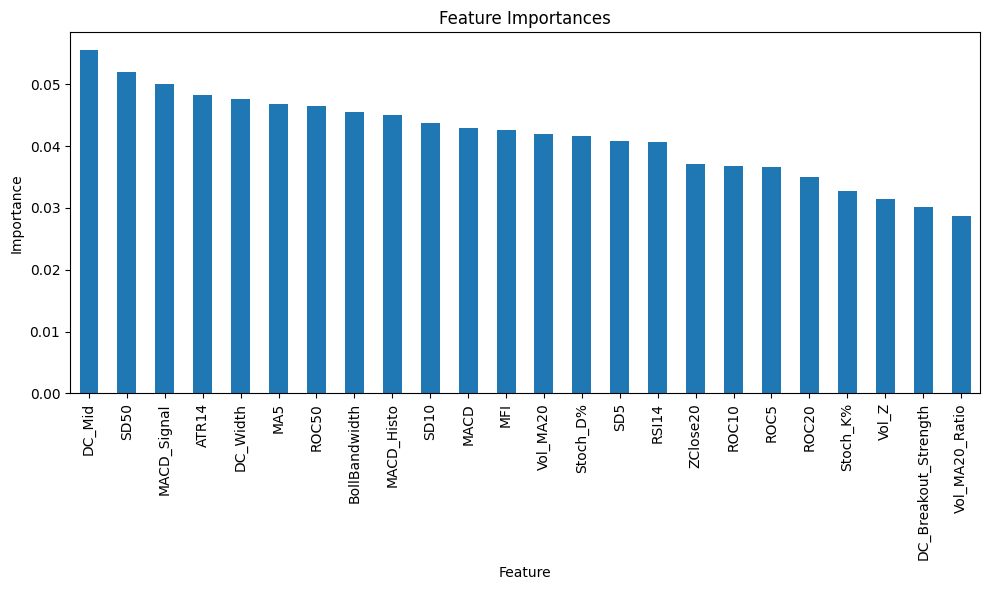

In [21]:
importances = clf.feature_importances_

feature_names = X_train.columns
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(importance_series)

plt.figure(figsize=(10, 6))
importance_series.plot(kind='bar')
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()